# Model Parameterization and Evaluation

## Metabolic Model Inputs

### Packages

In [1]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

import umap
import hdbscan

from matplotlib import pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

In [2]:
DATA_DIR = 'C:/Users/jakel/Desktop/Projects/media-prediction/'
TARGET = "taxon_id" # target label "media_id"
RANDOM_SEED = 26 # seed for random_state

### Dataset

In [3]:
df = pd.read_csv(os.path.join(DATA_DIR, "notebooks", "ml_input.csv"), low_memory=False)

filter = df["ec"].str.contains("-") # filter non-specific ec numbers, e.g., 1.1.1.-
df = df[~filter]

df = df[["taxon_id", "media_id", "ec"]].value_counts().reset_index()
df = df.pivot(index=["taxon_id", "media_id"], columns="ec", values="count")
df = df.fillna(0.0).reset_index()

# Filtering into training and test sets (database set vs. MAGs)
bins = df["media_id"].str.contains("unknown")
df_train = df[~bins]

# Create a mapping from media_id to a float and apply to dataframe
#media_id_mapping = {media_id: float(i) for i, media_id in enumerate(df_train['media_id'].unique())}
#df_train['media_id_float'] = df_train["media_id"].map(media_id_mapping)

print(len(df_train), "samples")
df_train.head()

8464 samples


ec,taxon_id,media_id,1.1.1.1,1.1.1.100,1.1.1.101,1.1.1.102,1.1.1.103,1.1.1.105,1.1.1.107,1.1.1.108,...,7.6.2.12,7.6.2.13,7.6.2.14,7.6.2.15,7.6.2.16,7.6.2.2,7.6.2.5,7.6.2.7,7.6.2.8,7.6.2.9
0,100.0,J346,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100.0,J386,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100225.0,J233,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1002526.0,J22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1004166.0,1a,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Model

### Testing parameters

In [4]:
# Model validation with only labeled samples from data.ipynb
X_train, X_test, y_train, y_test = train_test_split(
    df_train.drop(["taxon_id", "media_id"], axis=1),
    df_train[TARGET],
    test_size=0.2,
    random_state=RANDOM_SEED
)

#### Train_test_split checks

In [ ]:
# Checking the train_test_split IDs (baseline, taxonomy, etc.)
_, _, id_train, id_test = train_test_split(
    df_train[["taxon_id", "media_id"]],
    df_train[TARGET],
    test_size=0.2,
    random_state=RANDOM_SEED
)

train_df = id_train.to_frame() 
test_df = id_test.to_frame()

#train_df.to_csv(os.path.join("train.csv"), index=False)
#test_df.to_csv(os.path.join("test.csv"), index=False)

In [ ]:
from ete3 import NCBITaxa
from ete3.treeview import TreeStyle, NodeStyle, TextFace

# Data
train_taxa = set(train_df['taxon_id'].astype(float).astype(int))
test_taxa  = set(test_df['taxon_id'].astype(float).astype(int))
all_taxa   = list(train_taxa | test_taxa)

# Build tree
ncbi = NCBITaxa()
tree = ncbi.get_topology(all_taxa)
taxid_to_name = ncbi.get_taxid_translator(all_taxa)

for leaf in tree.iter_leaves():
    taxid = int(leaf.name)

    nstyle = NodeStyle()
    nstyle["size"] = 5
    nstyle["fgcolor"] = "black"
    leaf.set_style(nstyle)

    color = "red" if taxid in test_taxa else "black"
    leaf.add_face(TextFace(f"{taxid} ({taxid_to_name.get(taxid, 'Unknown')})", fgcolor=color, fsize=8), column=0, position="branch-right")

tree.render("split_tree.svg", w=800, units="px")
tree.write(outfile="split_tree.newick")

#TODO: move this somewhere else (save to data? idk--newick file can be used in lots of ways via NCBI)


#### Scoring (KMeans/silhouette)

In [6]:
import numpy as np
import random
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import umap

def randomized_umap_search(X, n_iter=30, n_clusters=50, random_state=RANDOM_SEED, sample_size=1000):
    rng = np.random.default_rng(random_state)
    
    results = []
    for _ in range(n_iter):
        n_components = rng.integers(2, 11)                
        n_neighbors = rng.integers(10, 101)            
        min_dist = rng.choice([0.0, 0.25, 0.5, 0.75, 1.0])
        
        try:
            reducer = umap.UMAP(
                n_components=n_components,
                n_neighbors=n_neighbors,
                min_dist=min_dist,
                metric="euclidean",
                random_state=random_state,
                n_epochs=25,
                low_memory=True,
                verbose=False
            )
            embedding = reducer.fit_transform(X)
            if np.isnan(embedding).any():
                continue

            km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
            labels = km.fit_predict(embedding)

            score = silhouette_score(
                embedding, labels,
                sample_size=min(sample_size, len(embedding)),
                random_state=random_state,
                metric="euclidean"
            )

            results.append({
                "n_components": n_components,
                "n_neighbors": n_neighbors,
                "min_dist": min_dist,
                "silhouette": score
            })
        except Exception as e:
            print(f"Skipping due to error: {e}")
            continue

    return sorted(results, key=lambda r: r["silhouette"], reverse=True)


In [7]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
print("UserWarnings disabled.") 

#best_results = randomized_umap_search(X_train, n_iter=30, n_clusters=50)
#print("Top 5:", best_results[:5])


UserWarnings disabled.


In [8]:
# UMAP reducer
model = umap.UMAP(             
        metric="euclidean",
        n_epochs=500, 
        random_state=RANDOM_SEED,
        n_jobs=1,
        n_components=6, #40
        n_neighbors=30,  #62
        min_dist=0
        )

# Fit and transform
X_train_transformed = model.fit_transform(X_train) # fit pipeline and transform training data
X_test_transformed = model.transform(X_test) # transform test data

#### Optimizing n_clusters

In [9]:
# Silhouette coefficient method
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Test a range of clusters for their silhouette coefficients
clusters = []
for n_cluster in range(50, 300):
    kmeans = KMeans(n_clusters=n_cluster).fit(X_train_transformed)
    label = kmeans.labels_
    sil_coeff = silhouette_score(X_train_transformed, label, metric='euclidean')
    clusters.append({'n_clusters': n_cluster, 'coefficient': sil_coeff})

# Select the maximum coefficient
clusters = pd.DataFrame(clusters)
c = clusters.iloc[clusters["coefficient"].argmax()]["n_clusters"]
s = clusters["coefficient"].max()
n = int(c)+1

print("{} clusters returns a maximum Silhouette Coefficient of {}".format(n, s))

c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


60 clusters returns a maximum Silhouette Coefficient of 0.7702954411506653


In [10]:
# Cluster using maximum coefficient's n_clusters
clusterer = KMeans(n_clusters=n, random_state=RANDOM_SEED)
training_clusters = clusterer.fit_predict(X_train_transformed)
test_clusters = clusterer.predict(X_test_transformed)

### Metrics

In [11]:
silhouette_avg = silhouette_score(X_train_transformed, training_clusters)
print(clusterer.labels_.max()+1, "KMeans training clusters")
print(f"Average Silhouette Score on KMeans clusters: {silhouette_avg}")
    # Silhouette score <=0.25 implies poor clustering, 0.25<x<=0.50 is fair, >50 is good

60 KMeans training clusters
Average Silhouette Score on KMeans clusters: 0.7576051950454712


## Classifier

In [52]:
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier

In [13]:
y2_train = training_clusters
y2_test = test_clusters

### Random Forest

In [14]:
rfc = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    random_state=RANDOM_SEED
)

rfc.fit(X_train_transformed, y2_train)
print(rfc.predict(X_test_transformed))

[53 33 31 ... 55 19 20]


In [15]:
report = classification_report(
    y_true=y2_test,
    y_pred=rfc.predict(X_test_transformed),
    zero_division=0.0 # Default: set to "warn", or float {0.0, 1.0}
)

roc_score = metrics.roc_auc_score(
    y_true=y2_test,
    y_score=rfc.predict_proba(X_test_transformed),
    labels=np.unique(y2_train),
    average="weighted",
    multi_class="ovo"
)

print(report)
print("RF ROC AUC score:", roc_score)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        24
           3       0.92      1.00      0.96        34
           4       1.00      0.99      0.99        74
           5       0.98      1.00      0.99        44
           6       1.00      1.00      1.00        19
           7       1.00      1.00      1.00        56
           8       1.00      1.00      1.00        30
           9       1.00      1.00      1.00        15
          10       1.00      1.00      1.00        31
          11       1.00      1.00      1.00        11
          12       1.00      1.00      1.00        47
          13       1.00      1.00      1.00        26
          14       1.00      1.00      1.00        11
          15       1.00      1.00      1.00        38
          16       0.83      1.00      0.91         5
          17       0.83    

### Nearest Neighbors

In [16]:
knc= KNeighborsClassifier(n_neighbors=1)
knc.fit(X_train_transformed, training_clusters)

X_test_reindexed = list(X_test_transformed) # is this mapping accurate?

distances, indices = knc.kneighbors(X_test_reindexed)

print(knc.predict(X_test_transformed))
indices

[53 33 31 ... 55 19 20]


array([[5144],
       [1040],
       [4814],
       ...,
       [5862],
       [3970],
       [5108]], shape=(1693, 1))

In [17]:
report = classification_report(
    y_true=y2_test,
    y_pred=knc.predict(X_test_transformed),
    zero_division=0.0 # Default: set to "warn", or float {0.0, 1.0}
)

roc_score = metrics.roc_auc_score(
    y_true=y2_test,
    y_score=knc.predict_proba(X_test_transformed),
    labels=np.unique(y2_train),
    average="weighted",
    multi_class="ovo"
)

print(report)
print("KNN ROC AUC score:", roc_score)

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        38
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        24
           3       0.97      1.00      0.99        34
           4       1.00      1.00      1.00        74
           5       1.00      1.00      1.00        44
           6       1.00      1.00      1.00        19
           7       1.00      1.00      1.00        56
           8       1.00      1.00      1.00        30
           9       1.00      1.00      1.00        15
          10       1.00      1.00      1.00        31
          11       1.00      1.00      1.00        11
          12       1.00      1.00      1.00        47
          13       1.00      1.00      1.00        26
          14       1.00      1.00      1.00        11
          15       1.00      1.00      1.00        38
          16       1.00      1.00      1.00         5
          17       1.00    

## Dataframes

In [18]:
# Training data
train_df = pd.DataFrame(X_train_transformed, columns=[f"Component {i+1}" for i in range(X_train_transformed.shape[1])])
train_df['Set'] = 'Training'
y_train_labels = list(y_train)
train_df['Target'] = y_train_labels
train_df['KMeans Cluster'] = training_clusters

# Media cluster labels
media_clusters = pd.read_csv(os.path.join(DATA_DIR, "data", "model", "media-clusters.csv"))
media_clusters = media_clusters[["media_id", "Media Cluster"]]
media_clusters = media_clusters.rename(columns={"media_id": "Target"})
target_label_mapping = dict(zip(media_clusters['Target'], media_clusters['Media Cluster']))
train_df['Media Cluster'] = train_df['Target'].map(target_label_mapping)

#train_df.to_csv(os.path.join(DATA_DIR, "data", "model", "param-train-output.csv"), index=False)

print(len(train_df))
train_df.head()

6771


,Component 1,Component 2,Component 3,Component 4,Component 5,Component 6,Set,Target,KMeans Cluster,Media Cluster
0,6.348855,2.269325,7.539920,8.667432,25.397596,11.242846,Training,340956.0,51,NaN
1,20.460596,-0.541904,6.920721,5.901127,-18.781321,10.815598,Training,85044.0,10,NaN
2,-0.121012,13.551844,-9.715377,22.762606,0.447743,18.980778,Training,380685.0,31,NaN
3,6.494005,5.269159,12.041254,8.750739,26.209345,8.995150,Training,394097.0,19,NaN
4,10.848492,14.062199,6.299933,3.677678,3.624182,-19.303228,Training,1258.0,7,NaN


In [19]:
# Test data
test_df = pd.DataFrame(X_test_transformed, columns=[f"Component {i+1}" for i in range(X_test_transformed.shape[1])])
test_df['Set'] = 'Test'
y_test_labels = list(y_test)
test_df['Target'] = y_test_labels
test_df['KMeans Cluster'] = test_clusters

# Add classifier labels 
test_df["KNN Classify"] = knc.predict(X_test_transformed)
test_df["RF Classify"] = rfc.predict(X_test_transformed)

#test_df.to_csv(os.path.join(DATA_DIR, "data", "model", "param-test-output.csv"), index=False)

print(len(test_df))
test_df.head()

1693


,Component 1,Component 2,Component 3,Component 4,Component 5,Component 6,Set,Target,KMeans Cluster,KNN Classify,RF Classify
0,-0.777068,13.196531,-10.728217,22.521677,-0.280962,19.478701,Test,1931.0,53,53,53
1,7.079556,0.586305,7.944576,10.198389,24.260523,10.647924,Test,850.0,33,33,33
2,-0.032810,13.379849,-9.643721,22.688805,0.523036,18.708828,Test,2220095.0,31,31,31
3,-0.112954,13.483487,-9.642658,22.643335,0.592316,19.009262,Test,1302236.0,31,31,31
4,11.143082,14.210817,6.164477,3.580599,3.518409,-19.626162,Test,1945634.0,7,7,7


In [20]:
# Add nearest neighbor indices to the test dataframe
knn_df = test_df.copy()
knn_df = knn_df.rename(columns={"KMeans Cluster": "Test Cluster"})
neighbors = pd.DataFrame(indices) # Indices of nearest neighbors from the training set
knn_df['indices'] = neighbors[neighbors.columns[0:]].apply(lambda x: ';'.join(x.dropna().astype(str)), axis=1)
knn_df["indices"] = knn_df["indices"].str.split(';')
knn_df = knn_df.explode("indices")

# Add original indices as a column for the train dataframe
    # Index maps to original dataframe before train_test_split!
    # Randomizes => inaccurate nearest neighbor mapping based on indices (fine if X_test and X_train are defined as in 05-Model-Test)
train_index = train_df.copy()
train_index = train_index.rename(columns={"KMeans Cluster": "Train Cluster"})
y_train_labels = pd.DataFrame(y_train).reset_index() # reset of index, TODO: ensure this is correct mapping!
train_index["indices"] = y_train_labels.index 
train_index["indices"] = train_index["indices"].astype(str)

# Merge to label nearest neighbors
left = knn_df.copy()
right = train_index[["indices", "Target", "Media Cluster"]] #"taxon_id", 
right = right.rename(columns={"Target": "neighbor_media_id", "Train Cluster": "neighbor_cluster", "Media Cluster": "neighbor_media_cluster"})
merged = pd.merge(left, right, on="indices", how="left")

#merged.to_csv(os.path.join(DATA_DIR, "data", "model", "param-model-output.csv"), index=False)
merged

,Component 1,Component 2,Component 3,Component 4,Component 5,Component 6,Set,Target,Test Cluster,KNN Classify,RF Classify,indices,neighbor_media_id,neighbor_media_cluster
0,-0.777068,13.196531,-10.728217,22.521677,-0.280962,19.478701,Test,1931.0,53,53,53,5144,1868378.0,NaN
1,7.079556,0.586305,7.944576,10.198389,24.260523,10.647924,Test,850.0,33,33,33,1040,217158.0,NaN
2,-0.032810,13.379849,-9.643721,22.688805,0.523036,18.708828,Test,2220095.0,31,31,31,4814,1309411.0,NaN
3,-0.112954,13.483487,-9.642658,22.643335,0.592316,19.009262,Test,1302236.0,31,31,31,5619,663608.0,NaN
4,11.143082,14.210817,6.164477,3.580599,3.518409,-19.626162,Test,1945634.0,7,7,7,5929,86957.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1688,10.502796,8.228717,9.484733,12.697537,19.279497,7.941638,Test,1871086.0,28,28,28,4507,1962118.0,NaN
1689,21.208429,10.748722,7.362488,-16.148136,4.662235,-1.100180,Test,1927.0,46,46,46,1611,1911.0,NaN
1690,-0.254685,13.823462,-8.533086,23.823940,-0.010275,20.383202,Test,412417.0,55,55,55,5862,439699.0,NaN
1691,6.584065,5.356683,11.983588,8.638391,26.175138,9.095712,Test,1874317.0,19,19,19,3970,76595.0,NaN


In [37]:
fig = px.scatter(
    data_frame = merged,
    x = "Component 1",
    y = "Component 2", 
    color = "Test Cluster",
    hover_data = ["Target"],
    #color_continuous_scale=px.colors.diverging.Picnic_r
    #color_continuous_scale=palette
    #opacity = 0.3
) 

fig.update_coloraxes(showscale=False) # hide color bar
fig.update_layout(
    template="plotly_white",
    showlegend=False,
    #width=500, 
    #height=500
)

import plotly.io as pio
#pio.renderers.default = "browser"
pio.renderers.default = "vscode"

fig.show()

## Feature Importance

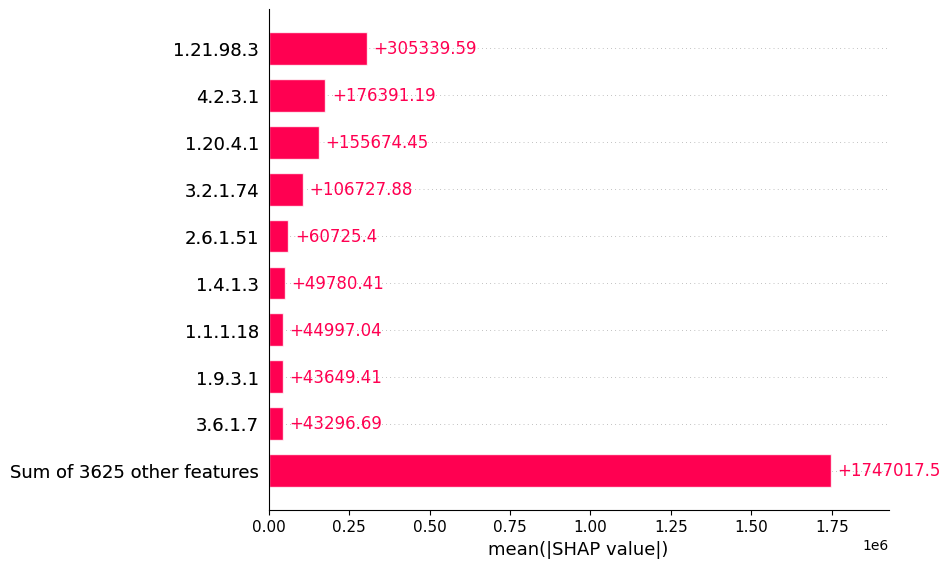

In [21]:
import xgboost
import shap

XG_train = df_train.drop(["taxon_id", "media_id"], axis=1)
yG_train = df_train["taxon_id"]

df_test = df[bins]
XG_test = df_test.drop(["taxon_id", "media_id"], axis=1)
yG_test = df_test["taxon_id"]

# train an XGBoost model
model = xgboost.XGBRegressor().fit(XG_train, yG_train)

# explain the model's predictions using SHAP
explainer = shap.Explainer(model)
shap_values = explainer(XG_test)

shap.plots.initjs()
#shap.plots.beeswarm(shap_values, max_display=11)
shap.plots.bar(shap_values, max_display=10)

[Text(0, 0, '   +305339.59'),
 Text(0, 0, '   +176391.19'),
 Text(0, 0, '   +155674.45'),
 Text(0, 0, '   +106727.88'),
 Text(0, 0, '   +60725.4'),
 Text(0, 0, '   +49780.04'),
 Text(0, 0, '   +44997.04'),
 Text(0, 0, '   +43649.41'),
 Text(0, 0, '   +43296.69'),
 Text(0, 0, '   +1747017.5')]

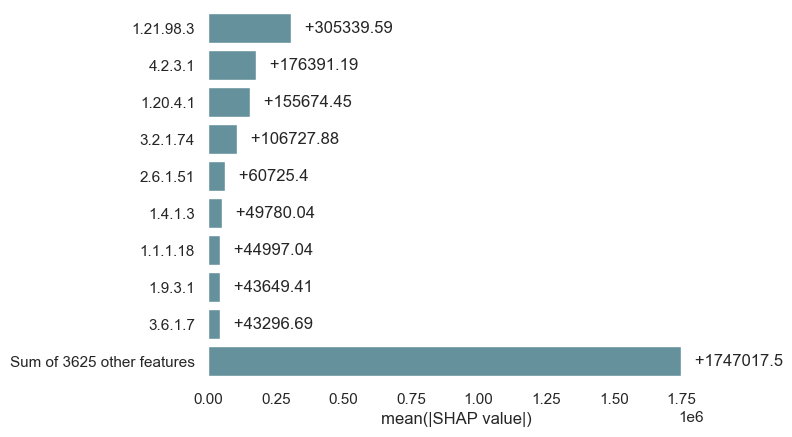

In [22]:
dict = {
    "features": ["1.21.98.3","4.2.3.1", "1.20.4.1", "3.2.1.74", "2.6.1.51", "1.4.1.3", "1.1.1.18", "1.9.3.1", "3.6.1.7", "Sum of 3625 other features"], #"4.1.1.17", 
    "importance": [305339.59, 176391.19, 155674.45, 106727.88, 60725.4, 49780.04, 44997.04, 43649.41, 43296.69, 1747017.5] #38625, 1708392.5
}

df = pd.DataFrame(dict)

df["labels"] = df["importance"].astype(str)
df["labels"] = "   +" + df["labels"]

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")
f, ax = plt.subplots()

sns.barplot(x="importance", y="features", data=df, color="#5c96a5")

ax.set(ylabel="", xlabel="mean(|SHAP value|)")
sns.despine(left=True, bottom=True)
ax.bar_label(ax.containers[0], labels=df["labels"])

# Media Model

In [ ]:
#TODO: move/incorporate this box of code with 01-Data.ipynb

#import sys
#sys.path.append("..")

#med_df = pd.read_csv(os.path.join(DATA_DIR, "data", "mediadive", "mediadive-all.csv"), sep=";")
#med_ids = med_df["media_id"].to_list()
#id_list = set(med_ids)
#print(len(id_list))

#import modules.mediadive as md
#mediadive_complete = md.get_concentrations(id_list)

#mediadive_complete.to_csv(os.path.join(DATA_DIR, "data", "mediadive", "mediadive-complete.csv"), index=False)
#mediadive_complete.head()

In [32]:
# Load dataframe from box above and reformat to target component_ids
mediadive_complete = pd.read_csv(os.path.join(DATA_DIR, "data", "mediadive", "mediadive-complete.csv"), low_memory=False)

mediadive_complete = mediadive_complete.replace(r'[\[\]]', '', regex=True)
mediadive_complete['component_ids'] = mediadive_complete['component_ids'].str.split(r',\s*')
df_exploded = mediadive_complete.explode('component_ids', ignore_index=True)
media_df = df_exploded[["media_id", "component_ids"]]

media_df.head()

,media_id,component_ids
0,J815,42
1,J815,8
2,J815,7
3,J815,4
4,J815,1900


In [33]:
# Reformat  for presence/absence and remove water as a component
df = media_df[["media_id", "component_ids"]].value_counts().reset_index()
df = df.pivot(index="media_id", columns="component_ids", values="count")
df = df.fillna(0.0)
df = df.map(lambda x: 1.0 if x > 0 else 0.0).reset_index() # make binary

df = df.drop("4", axis=1) # drop water as an ingredient, consider other "universal" features, or use sklearn "feature selection"

df.head()

component_ids,media_id,,1,10,1000,1002,1005,101,1010,1015,...,983,984,987,988,989,99,990,991,992,994
0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
# Scorer for UMAP cndtns and KMeans clusters
import random

def umap_kmeans_random_search(data, n_neighbors_range, n_clusters_range, n_iter=10, random_state=42):

    results = []
    random.seed(random_state)
    
    for _ in range(n_iter):
        n_neighbors = random.choice(n_neighbors_range)
        n_clusters = random.choice(n_clusters_range)
        
        # UMAP embedding
        reducer = umap.UMAP(
            n_neighbors=n_neighbors,
            n_components=2,
            metric='euclidean',
            random_state=random_state,
            n_epochs=500,
            min_dist=0,
            n_jobs=1
        )
        embedding = reducer.fit_transform(data)
        
        kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
        labels = kmeans.fit_predict(embedding)
        
        score = silhouette_score(embedding, labels)
        
        results.append({
            'n_neighbors': n_neighbors,
            'n_clusters': n_clusters,
            'silhouette_score': score
        })
    
    return results


In [35]:
# scorer usage
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" #RuntimeWarning prevention
X = df.drop("media_id", axis=1)

n_neighbors_range = range(10, 101, 10) 
n_clusters_range = range(2, 201)   

results = umap_kmeans_random_search(X, n_neighbors_range, n_clusters_range, n_iter=15, random_state=RANDOM_SEED)

#best = max(results, key=lambda r: r['silhouette_score'])
#print("Best params:", best)

#TODO: Check warning here (system specific)


c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [54]:
df.head()

component_ids,media_id,,1,10,1000,1002,1005,101,1010,1015,...,983,984,987,988,989,99,990,991,992,994
0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Model validation with only labeled samples from media df
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(["media_id"], axis=1),
    df["media_id"],
    test_size=0.2,
    random_state=RANDOM_SEED
)

import umap

reducer = umap.UMAP(             
    metric="euclidean",
    n_epochs=500, 
    random_state=RANDOM_SEED,
    n_jobs=1,
    n_components=2,
    n_neighbors=10, #97
    min_dist=0
)

# Fit and transform
X_train_transformed = reducer.fit_transform(X_train) 
X_test_transformed = reducer.transform(X_test)

In [57]:
# Cluster 
clusterer = KMeans(n_clusters=172, random_state=RANDOM_SEED)
training_clusters = clusterer.fit_predict(X_train_transformed)
silhouette_avg = silhouette_score(X_train_transformed, training_clusters)
print(clusterer.labels_.max()+1, "KMeans training clusters")
print(f"Average Silhouette Score on KMeans clusters: {silhouette_avg}")

# Dataframe
train_df = pd.DataFrame(X_train_transformed, columns=[f"Component {i+1}" for i in range(X_train_transformed.shape[1])])
y_train_labels = list(df["media_id"])
train_df['Target'] = y_train_labels
train_df['KMeans Cluster'] = training_clusters

print(len(train_df), "training points")

172 KMeans training clusters
Average Silhouette Score on KMeans clusters: 0.6068054437637329


ValueError: Length of values (3324) does not match length of index (2659)

In [47]:
#palette=["#2BD8D8", "#FCB019"]
#palette=["#FC0B0B", "#F5B139"] 
#palette=["#0772A7", "#F5B139"] # palette for two clusters

fig = px.scatter(
    data_frame = train_df,
    x = "Component 1",
    y = "Component 2", 
    color = "KMeans Cluster",
    hover_data = ["Target"],
    #color_continuous_scale=px.colors.diverging.Picnic_r
    #color_continuous_scale=palette
    #opacity = 0.3
) 

fig.update_coloraxes(showscale=False) # hide color bar
fig.update_layout(
    template="plotly_white",
    showlegend=False,
    #width=500, 
    #height=500
)

import plotly.io as pio
#pio.renderers.default = "browser"
pio.renderers.default = "vscode"

fig.show()

In [48]:
# Saving the media clusters to a df for labeling other ml outputs
train_df = train_df.rename(columns={"Target": "media_id", "KMeans Cluster": "Media Cluster"})
#train_df = train_df.drop(["Component 1", "Component 2"], axis=1)
#train_df.to_csv(os.path.join(DATA_DIR, "data", "model", "media-clusters.csv"), index=False)
train_df.head()

,Component 1,Component 2,media_id,Media Cluster
0,19.149456,12.967528,1,66
1,18.906437,11.568596,10,129
2,2.856487,12.420313,1000,10
3,0.065634,11.674104,1001,65
4,10.507472,4.123113,1002,134


In [53]:
# Clusters
#y2_train = training_clusters
y2_test = train_df["Media Cluster"]

# Classifier
rfc = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    random_state=RANDOM_SEED
)

#rfc.fit(X_train_transformed, y2_train)
rfc.fit(X_train_transformed, y)
print(rfc.predict(X_test_transformed))

# Reports
report = classification_report(
    y_true=y2_test,
    y_pred=rfc.predict(X_test_transformed),
    zero_division=0.0 # Default: set to "warn", or float {0.0, 1.0}
)

roc_score = metrics.roc_auc_score(
    y_true=y2_test,
    y_score=rfc.predict_proba(X_test_transformed),
    labels=np.unique(y2_train),
    average="weighted",
    multi_class="ovo"
)

print(report)
print("RF ROC AUC score:", roc_score)

NameError: name 'y' is not defined